In [1]:
# change working directory to PNAS_REVIEW - persistent, so restart kernel needed
%cd /home/andreasstillits/coding/Leaves1D/PNAS_REVIEW

/home/andreasstillits/coding/Leaves1D/PNAS_REVIEW


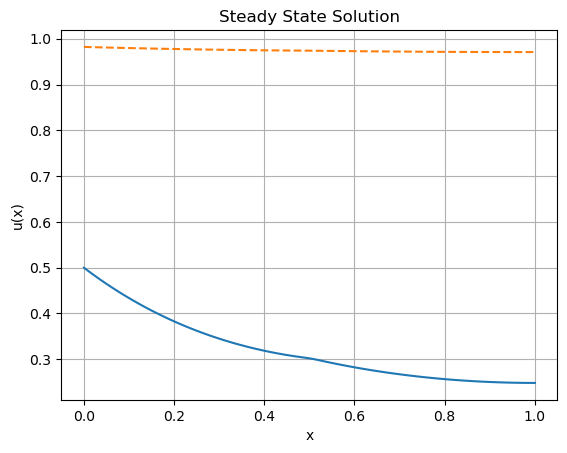

In [7]:
from review.steady.solver import SteadySolver 
from review.nonlinear.solver import NonlinearSolver
from review.utils.profiles import StepProfile
import matplotlib.pyplot as plt

params = [2, 2, 0.1]

delta = StepProfile()
delta.populate_rho(0.5, 0.5) 

kappa = StepProfile()
kappa.populate_rho(0.3, 0.5)

solver = SteadySolver(params,
                      delta = delta.steadify(),
                      kappa = kappa.steadify())

domain, solution = solver.solve()

plt.plot(domain, solution)

mu = 100
nonlinear_solver = NonlinearSolver(params,
                                    mu = mu,
                                    delta = delta.steadify(),
                                    kappa = kappa.steadify())

domain_nl, solution_nl = nonlinear_solver.solve()

plt.plot(domain_nl, solution_nl, '--')


plt.xlabel('x')
plt.ylabel('u(x)')
# plt.ylim(0, 1.1)
plt.title('Steady State Solution')
plt.grid()
plt.show()

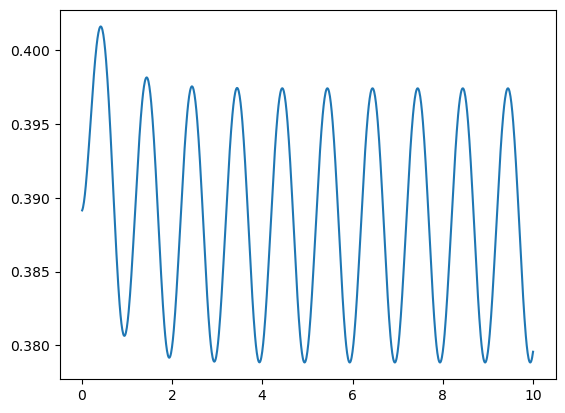

In [3]:
from review.temporal.solver import TemporalSolver
from review.utils.profiles import OscillatorProfile

params = [1, 1, 0.1]

osc = OscillatorProfile(0.2, 1.0)

solver = TemporalSolver(params, timing=(0, 10, 0.01), update_stomata=osc.generalize())
domain, solution = solver.solve()


plt.plot(domain, solution)
